In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler
import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

datos, metadatos = tfds.load("mnist", with_info=True, as_supervised=True)
datos_entrenamiento, datos_prueba = datos["train"], datos["test"]

In [3]:
nombres_clases = [
    "Cero",
    "Uno",
    "Dos",
    "Tres",
    "Cuatro",
    "Cinco",
    "Seis",
    "Siete",
    "Ocho",
    "Nueve",
]

num_ejemplos_entrenamiento = metadatos.splits["train"].num_examples
num_ejemplos_prueba = metadatos.splits["test"].num_examples

In [4]:
def normalizar(imagen, etiqueta):
    imagen = tf.cast(imagen, tf.float32)
    imagen /= 255
    return imagen, etiqueta

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_prueba = datos_prueba.map(normalizar)
datos_entrenamiento = datos_entrenamiento.cache()
datos_prueba = datos_prueba.cache()

In [5]:
modelo = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
        tf.keras.layers.Dense(64, activation=tf.nn.relu),
        tf.keras.layers.Dense(64, activation=tf.nn.relu),
        tf.keras.layers.Dense(10, activation=tf.nn.softmax),
    ]
)

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [6]:
TAMANO_LOTE = 32
num_ejemplos_entrenamiento = metadatos.splits["train"].num_examples
num_ejemplos_prueba = metadatos.splits["test"].num_examples
print("Número de ejemplos de entrenamiento:", num_ejemplos_entrenamiento)
print("Número de ejemplos de prueba:", num_ejemplos_prueba)
datos_entrenamiento = (
    datos_entrenamiento.repeat().shuffle(num_ejemplos_entrenamiento).batch(TAMANO_LOTE)
)
datos_prueba = (
    datos_prueba.batch(TAMANO_LOTE)
)

Número de ejemplos de entrenamiento: 60000
Número de ejemplos de prueba: 10000


Epoch 1/10
1875/1875 [==============================] - 4s 1ms/step - loss: 0.2689 - accuracy: 0.9213
Epoch 2/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.1211 - accuracy: 0.9635
Epoch 3/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0859 - accuracy: 0.9735
Epoch 4/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0693 - accuracy: 0.9783
Epoch 5/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0549 - accuracy: 0.9826
Epoch 6/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0458 - accuracy: 0.9849
Epoch 7/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0409 - accuracy: 0.9870
Epoch 8/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0358 - accuracy: 0.9887
Epoch 9/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0304 - accuracy: 0.9901
Epoch 10/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.026

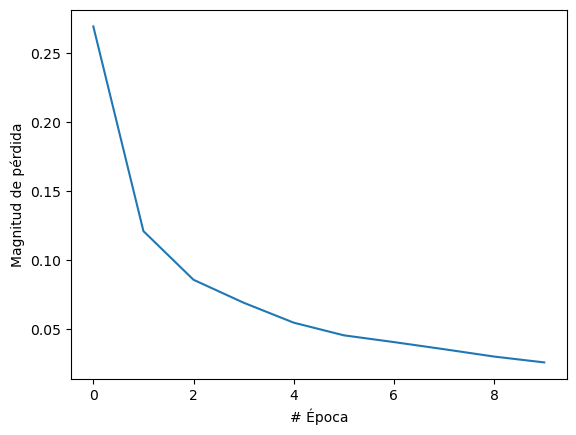

In [7]:
historial = modelo.fit(
    datos_entrenamiento,
    epochs=10,
    steps_per_epoch=math.ceil(num_ejemplos_entrenamiento / TAMANO_LOTE),
)

plt.xlabel("# Época")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.show()

In [ ]:
class ManejadorHTTP(BaseHTTPRequestHandler):
    def do_OPTIONS(self):
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.send_header("Access-Control-Allow-Methods", "POST, OPTIONS")
        self.send_header("Access-Control-Allow-Headers", "Content-Type, Content-Length")
        self.end_headers()

    def do_POST(self):
        print("Petición recibida")
        # Obtiene y limpia los datos enviados desde el HTML
        longitud = int(self.headers["Content-Length"])
        datos_recibidos = self.rfile.read(longitud)
        datos_recibidos = datos_recibidos.decode().replace("pixeles=", "")
        datos_recibidos = parse.unquote(datos_recibidos)

        # Transforma los píxeles al formato que usa el modelo (1, 28, 28, 1)
        arreglo = np.fromstring(datos_recibidos, np.float32, sep=",")
        arreglo = arreglo.reshape(28, 28)
        arreglo = np.array(arreglo)
        arreglo = arreglo.reshape(1, 28, 28, 1)

        # Realiza la predicción
        valores_prediccion = modelo.predict(arreglo, batch_size=1)
        prediccion = str(np.argmax(valores_prediccion))
        print("Predicción final: " + prediccion)

        # Regresa la respuesta al HTML
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.send_header("Access-Control-Allow-Methods", "POST, OPTIONS")
        self.send_header("Access-Control-Allow-Headers", "Content-Type, Content-Length")
        self.send_header("Content-Type", "text/plain") 
        self.end_headers()
        self.wfile.write(prediccion.encode())

    def log_message(self, format, *args):
        pass  

# Inicia el servidor en el puerto 8000
print("Iniciando el servidor en http://localhost:8000 ...")
servidor = HTTPServer(("localhost", 8000), ManejadorHTTP)
servidor.serve_forever()

Iniciando el servidor en http://localhost:8000 ...
Petición recibida
1/1 [==============================] - 0s 92ms/step
Predicción final: 7
Petición recibida
1/1 [==============================] - 0s 22ms/step
Predicción final: 8
Petición recibida
1/1 [==============================] - 0s 27ms/step
Predicción final: 5
Petición recibida
1/1 [==============================] - 0s 22ms/step
Predicción final: 1
Petición recibida
1/1 [==============================] - 0s 22ms/step
Predicción final: 1
Petición recibida
1/1 [==============================] - 0s 20ms/step
Predicción final: 1
Petición recibida
1/1 [==============================] - 0s 22ms/step
Predicción final: 5
Petición recibida
1/1 [==============================] - 0s 21ms/step
Predicción final: 8
Petición recibida
1/1 [==============================] - 0s 22ms/step
Predicción final: 4
Petición recibida
1/1 [==============================] - 0s 21ms/step
Predicción final: 1
Petición recibida
1/1 [==========================